In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')


In [5]:
# Chart styling settings
sns.set_theme(style="whitegrid", palette="muted")

plt.rcParams.update({
    'figure.dpi': 150,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12
})

# Custom colors
BLUE   = "#2563EB"
GREEN  = "#16A34A"
RED    = "#DC2626"
ORANGE = "#EA580C"
GRAY   = "#6B7280"

In [8]:
df = pd.read_csv('D:\Ecommerce-Sales-Intelligence\data\cleaned_retail_data.csv', parse_dates=['invoicedate'])
print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['invoicedate'].min().date()} → {df['invoicedate'].max().date()}")

✅ Loaded: 805,549 rows × 16 columns
Date range: 2009-12-01 → 2011-12-09


In [9]:
print("\n📊 KEY METRICS")
print("=" * 40)
total_revenue    = df['total_revenue'].sum()
total_orders     = df['invoice'].nunique()
unique_customers = df['customer_id'].nunique()
unique_products  = df['stockcode'].nunique()
aov              = total_revenue / total_orders
avg_clv          = total_revenue / unique_customers

print(f"Total Revenue:       £{total_revenue:>12,.2f}")
print(f"Total Orders:        {total_orders:>12,}")
print(f"Unique Customers:    {unique_customers:>12,}")
print(f"Unique Products:     {unique_products:>12,}")
print(f"Avg. Order Value:    £{aov:>12,.2f}")
print(f"Avg. Customer LTV:   £{avg_clv:>12,.2f}")


📊 KEY METRICS
Total Revenue:       £17,743,429.18
Total Orders:              36,969
Unique Customers:           5,878
Unique Products:            4,631
Avg. Order Value:    £      479.95
Avg. Customer LTV:   £    3,018.62


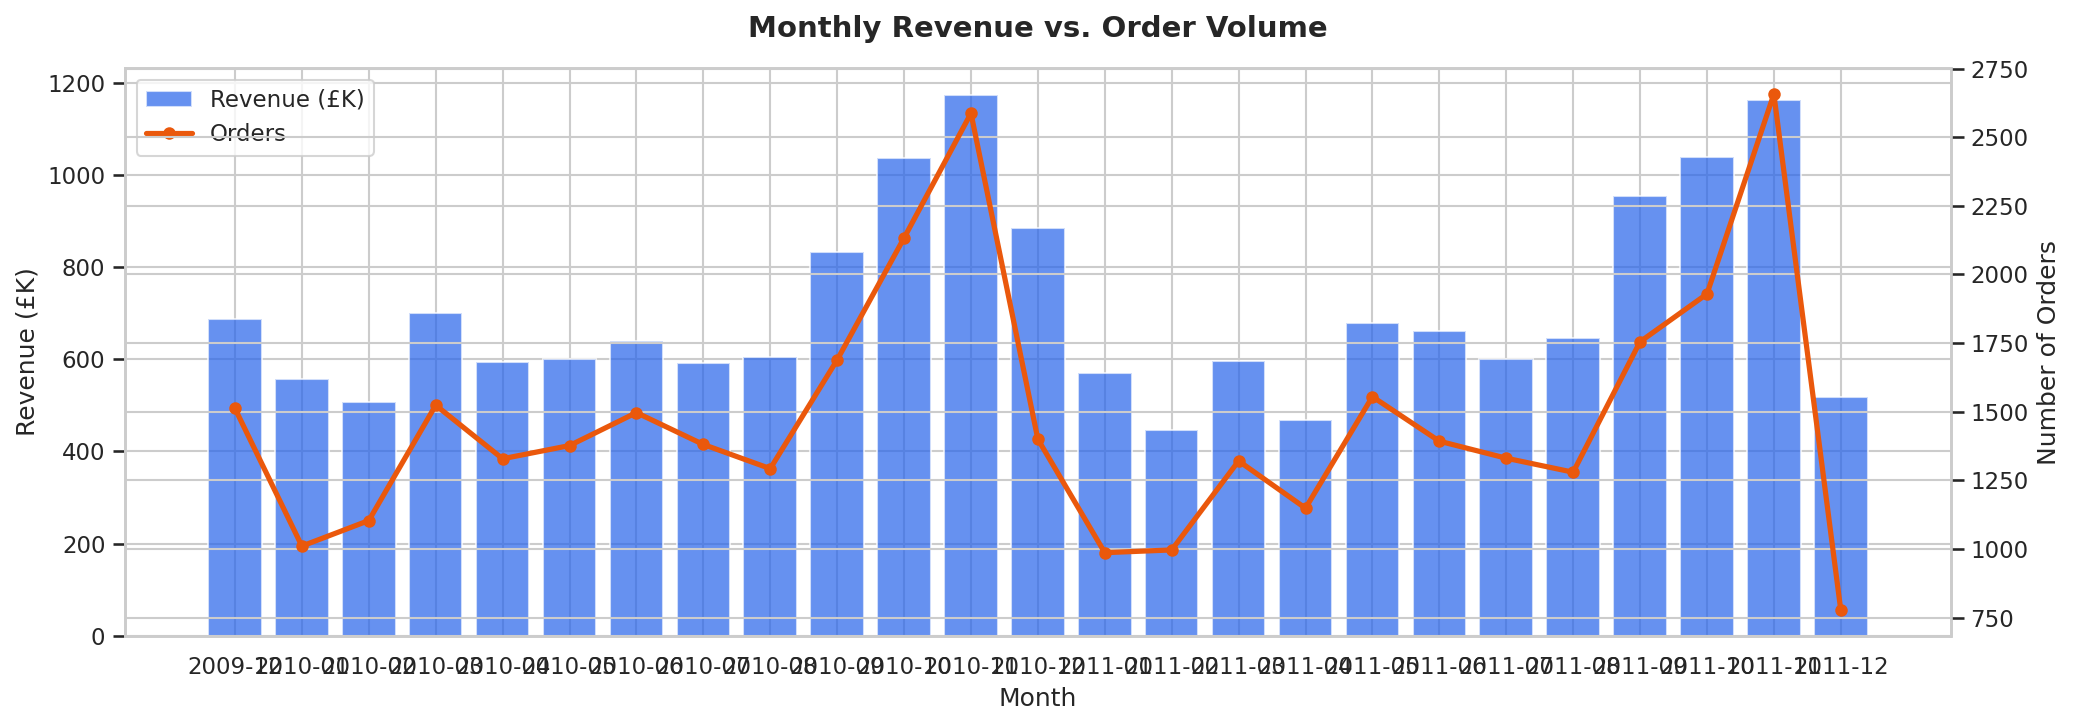

✅ Saved: 01_monthly_revenue_trend.png


In [13]:
# ─── CHART 1: Monthly Revenue Trend ─────────────────────────────────────────
monthly = (df.groupby('year_month')
             .agg(revenue=('total_revenue', 'sum'),
                  orders=('invoice', 'nunique'))
             .reset_index()
             .sort_values('year_month'))

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.bar(monthly['year_month'], monthly['revenue'] / 1000,
        color=BLUE, alpha=0.7, label='Revenue (£K)')
ax2.plot(monthly['year_month'], monthly['orders'],
         color=ORANGE, linewidth=2.5, marker='o', markersize=5, label='Orders')

ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (£K)')
ax2.set_ylabel('Number of Orders')
ax1.set_title('Monthly Revenue vs. Order Volume', fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/01_monthly_revenue_trend.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 01_monthly_revenue_trend.png")

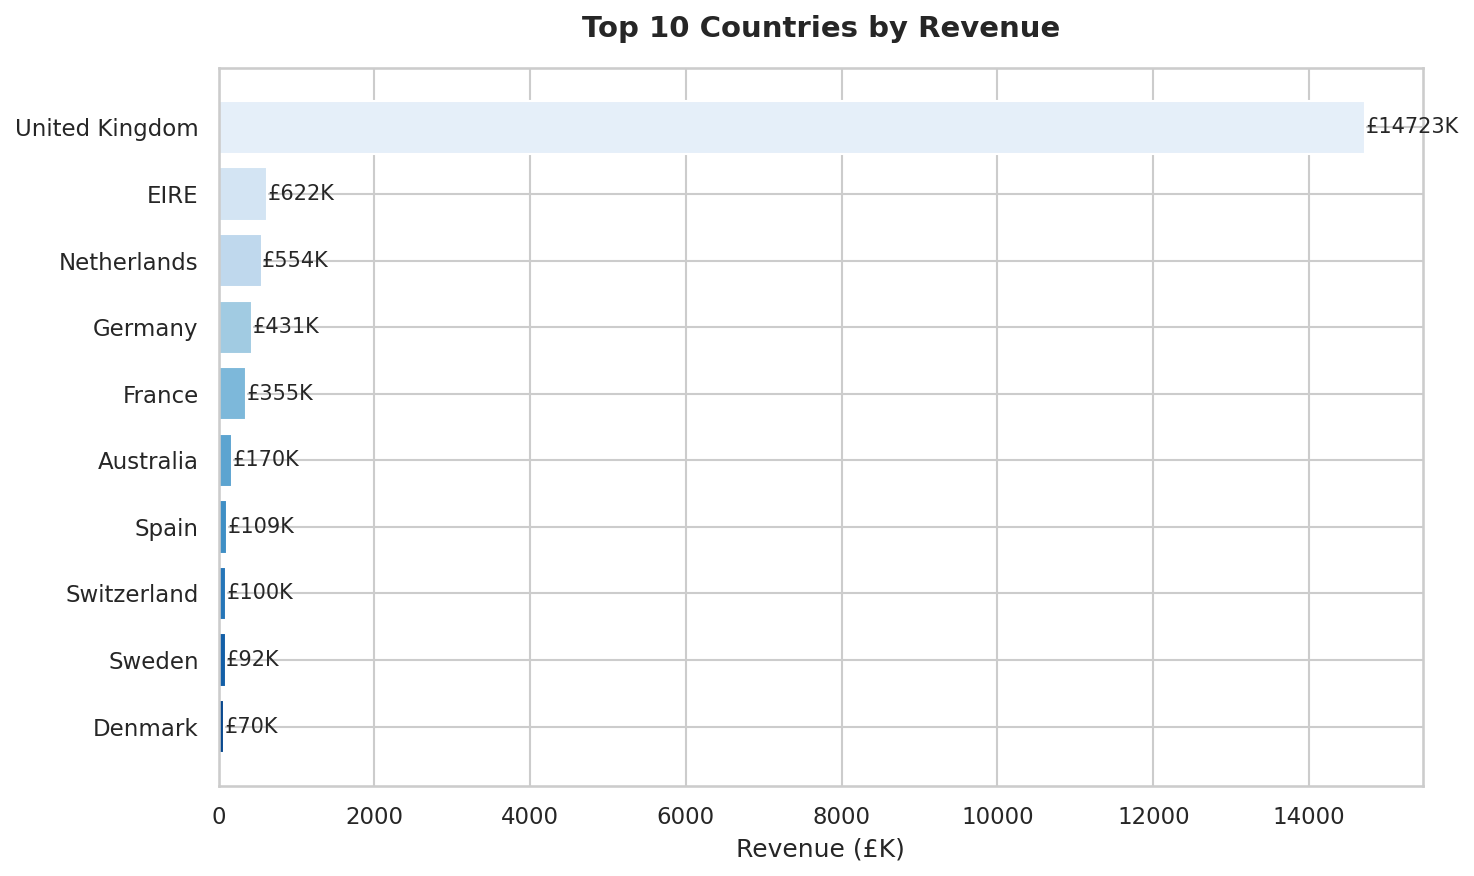

In [14]:
# ─── CHART 2: Revenue by Country (Top 10) ────────────────────────────────────
country_rev = (df.groupby('country')['total_revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(country_rev['country'][::-1],
               country_rev['total_revenue'][::-1] / 1000,
               color=sns.color_palette("Blues_r", 10))

for bar, val in zip(bars, country_rev['total_revenue'][::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.0f}K', va='center', fontsize=10)

ax.set_xlabel('Revenue (£K)')
ax.set_title('Top 10 Countries by Revenue', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/02_revenue_by_country.png', bbox_inches='tight')
plt.show()


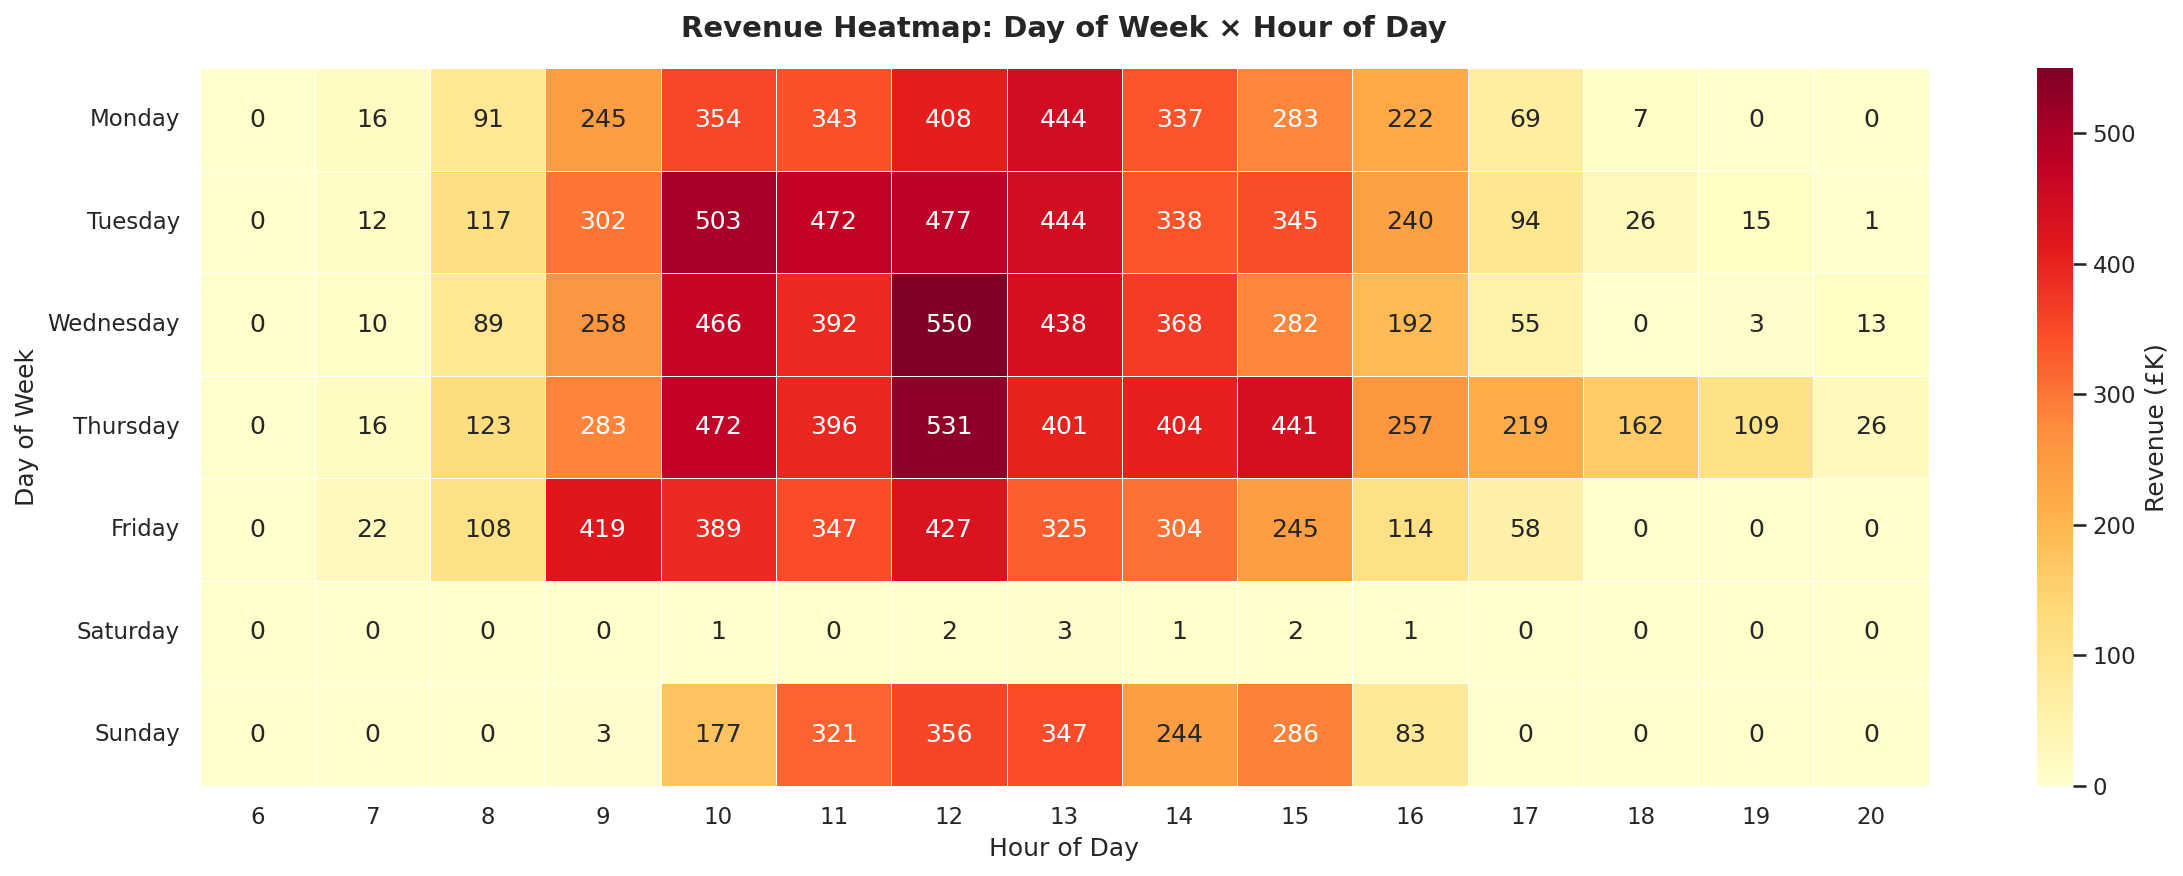

In [15]:
# ─── CHART 3: Sales Heatmap — Hour × Day of Week ─────────────────────────────
# Shows when customers are most active
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
heatmap_data = (df.groupby(['day_of_week', 'invoice_hour'])['total_revenue']
                  .sum()
                  .unstack(fill_value=0))
heatmap_data = heatmap_data.reindex(dow_order)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(heatmap_data / 1000,
            cmap='YlOrRd',
            ax=ax,
            linewidths=0.3,
            fmt='.0f',
            annot=True,
            cbar_kws={'label': 'Revenue (£K)'})
ax.set_title('Revenue Heatmap: Day of Week × Hour of Day', fontweight='bold', pad=15)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/03_sales_heatmap.png', bbox_inches='tight')
plt.show()


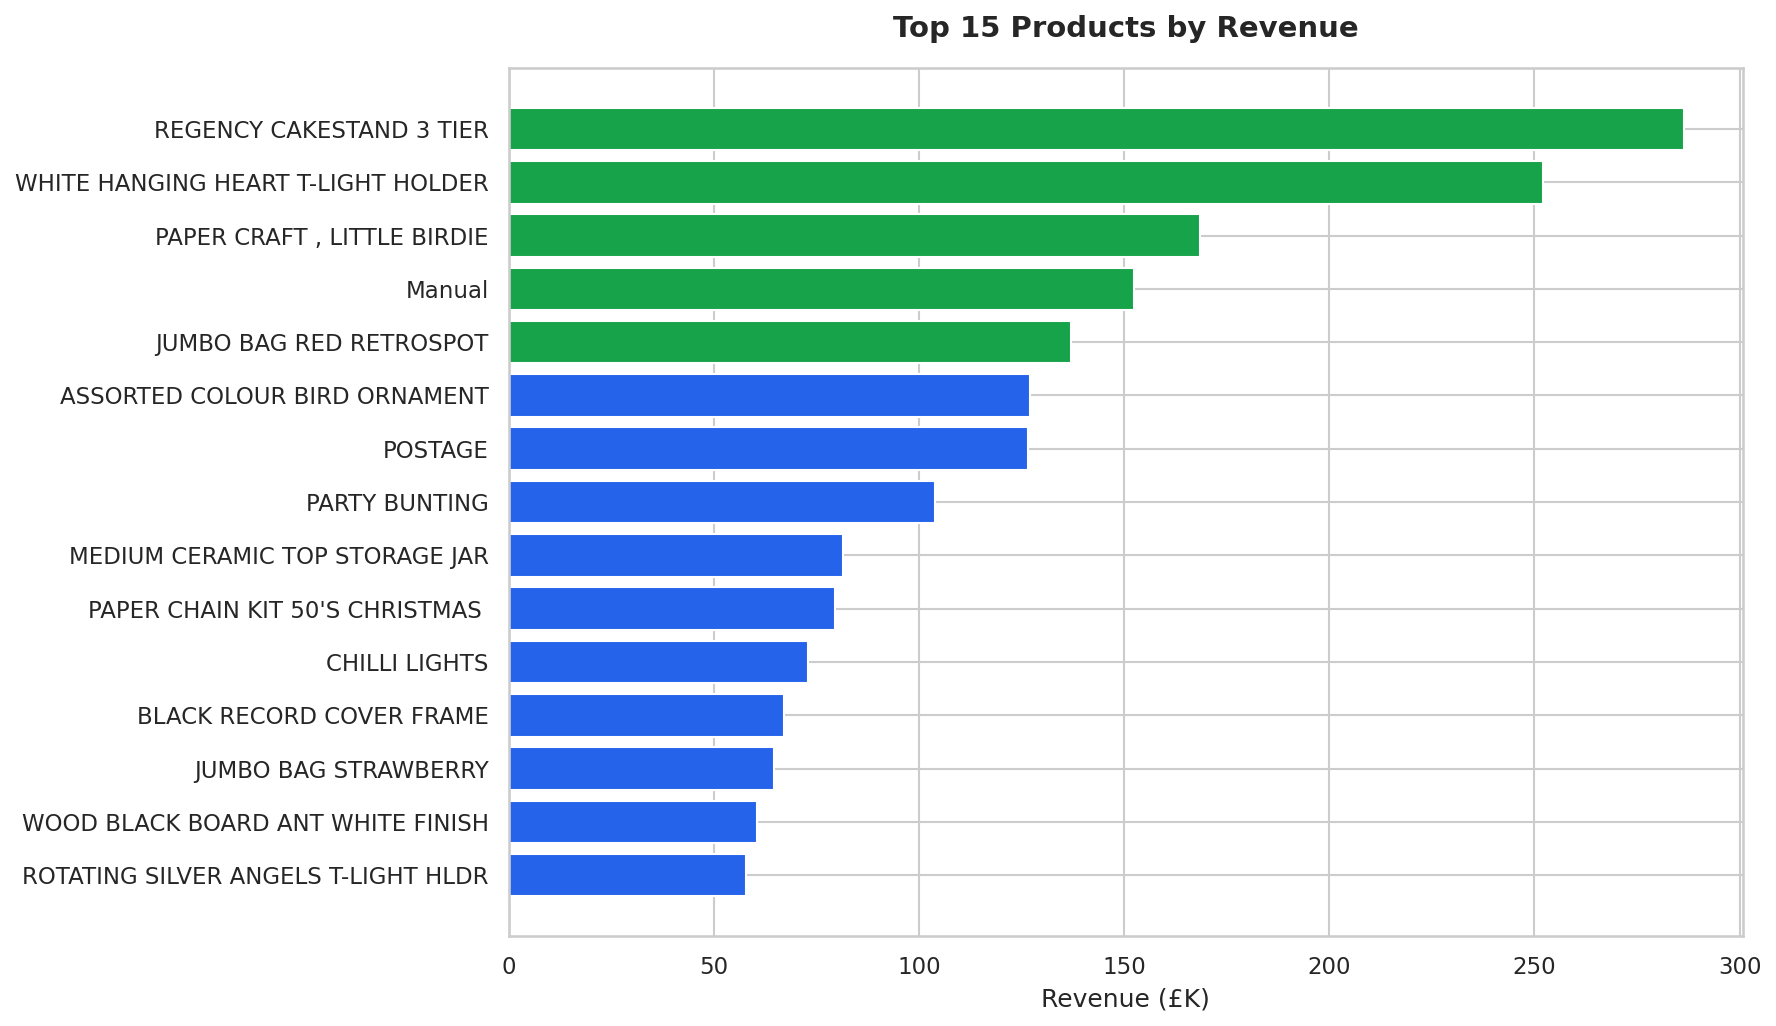

In [17]:
# ─── CHART 4: Top 15 Products by Revenue ────────────────────────────────────
top_products = (df.groupby('description')
                  .agg(revenue=('total_revenue', 'sum'),
                       qty=('quantity', 'sum'))
                  .sort_values('revenue', ascending=False)
                  .head(15)
                  .reset_index())

fig, ax = plt.subplots(figsize=(12, 7))
colors = [GREEN if i < 5 else BLUE for i in range(15)]
bars = ax.barh(top_products['description'][::-1],
               top_products['revenue'][::-1] / 1000,
               color=colors[::-1])

ax.set_xlabel('Revenue (£K)')
ax.set_title('Top 15 Products by Revenue', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/04_top_products.png', bbox_inches='tight')
plt.show()

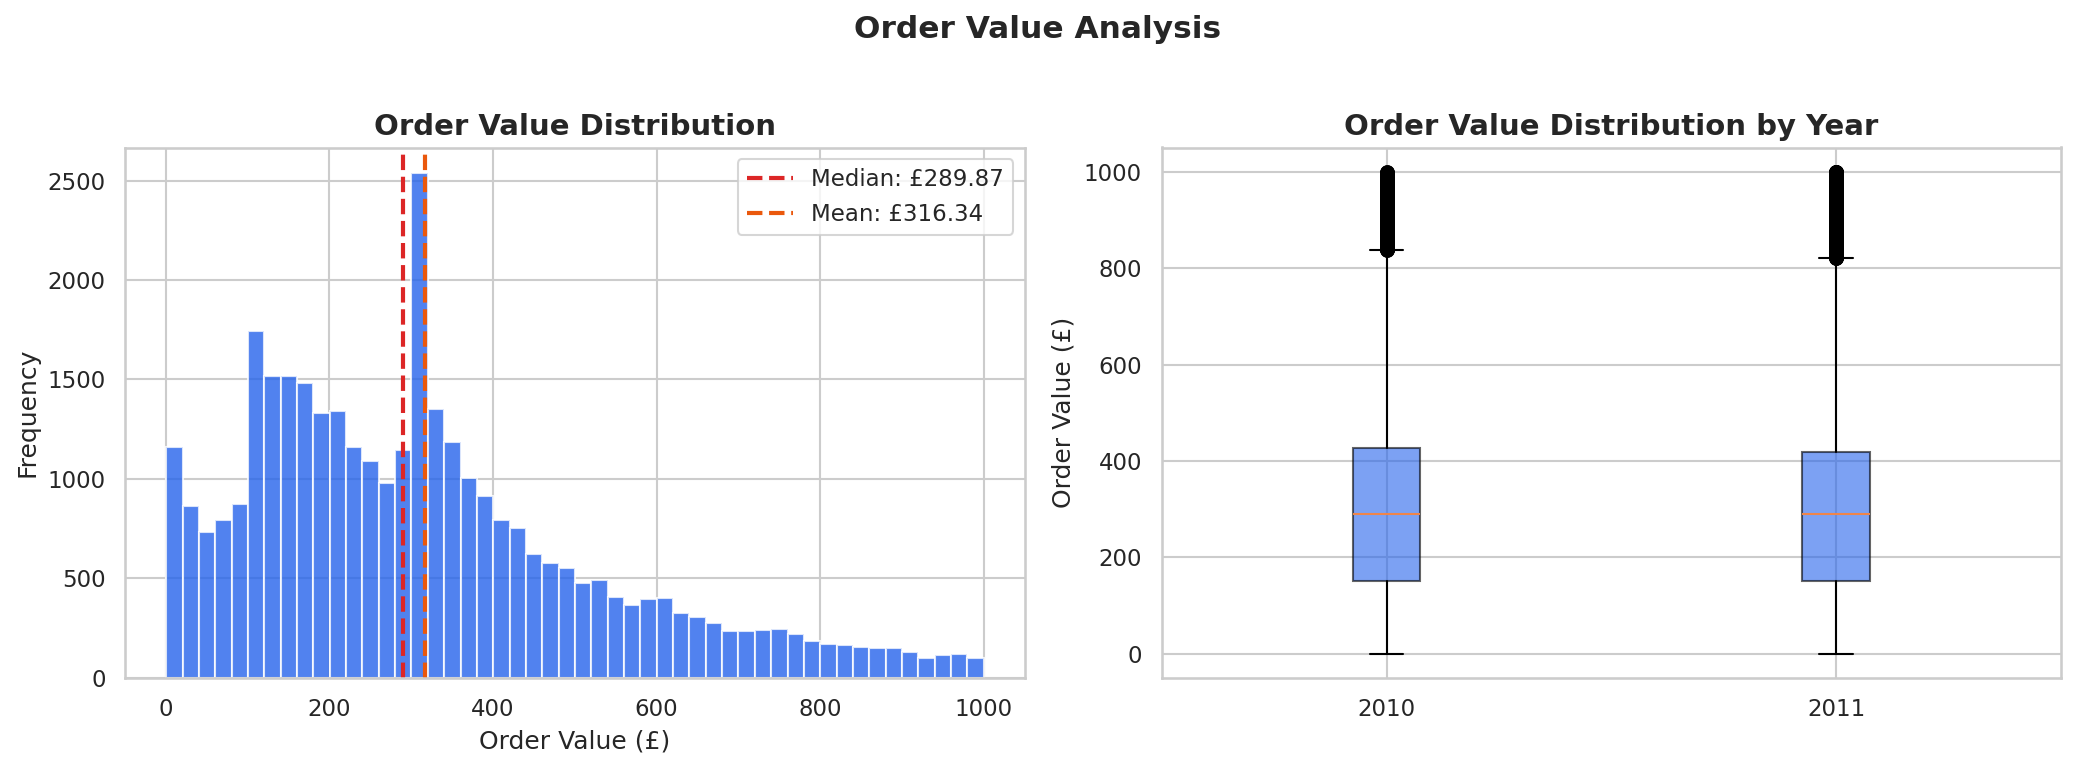

In [19]:
# ─── CHART 5: Order Value Distribution ──────────────────────────────────────
invoice_values = (df.groupby('invoice')['total_revenue']
                    .sum()
                    .reset_index())
invoice_values = invoice_values[invoice_values['total_revenue'] <= 1000]  # Exclude extreme outliers

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(invoice_values['total_revenue'], bins=50, color=BLUE, alpha=0.8, edgecolor='white')
axes[0].axvline(invoice_values['total_revenue'].median(), color=RED, linestyle='--',
                linewidth=2, label=f"Median: £{invoice_values['total_revenue'].median():.2f}")
axes[0].axvline(invoice_values['total_revenue'].mean(), color=ORANGE, linestyle='--',
                linewidth=2, label=f"Mean: £{invoice_values['total_revenue'].mean():.2f}")
axes[0].set_title('Order Value Distribution', fontweight='bold')
axes[0].set_xlabel('Order Value (£)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Box plot by year
df_2010 = df[df['invoice_year'] == 2010]
df_2011 = df[df['invoice_year'] == 2011]
order_by_year = []
labels = []
for yr, d in [(2010, df_2010), (2011, df_2011)]:
    vals = d.groupby('invoice')['total_revenue'].sum()
    vals = vals[vals <= 1000]
    order_by_year.append(vals.values)
    labels.append(str(yr))

axes[1].boxplot(order_by_year, labels=labels, patch_artist=True,
                boxprops=dict(facecolor=BLUE, alpha=0.6))
axes[1].set_title('Order Value Distribution by Year', fontweight='bold')
axes[1].set_ylabel('Order Value (£)')

plt.suptitle('Order Value Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/05_order_value_distribution.png', bbox_inches='tight')
plt.show()


📐 STATISTICAL SUMMARY — Order Values
  count       : £ 36,969.00
  mean        : £    479.95
  std         : £  1,374.99
  min         : £      0.38
  25%         : £    160.80
  50%         : £    305.25
  75%         : £    489.26
  90%         : £    851.67
  95%         : £  1,253.78
  99%         : £  3,697.92
  max         : £168,469.60

  Skewness: 59.61  (>0 = right-skewed)
  Kurtosis: 6389.51


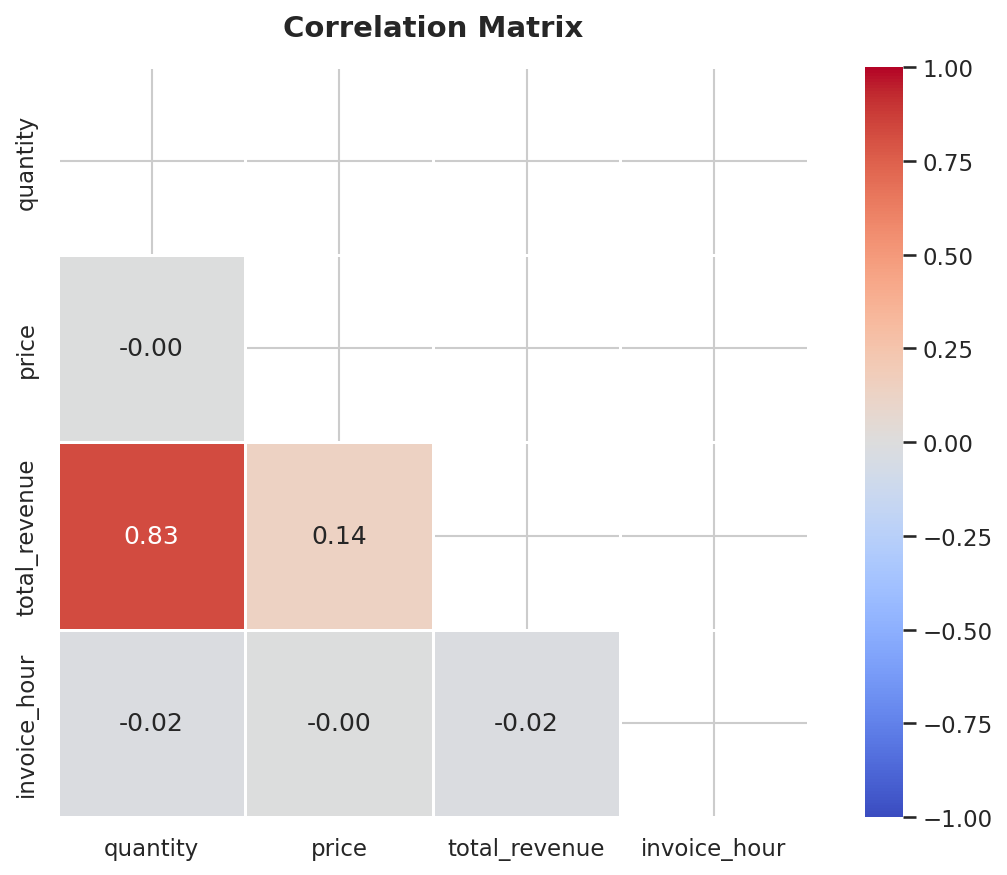

In [21]:
# ─── STATISTICAL ANALYSIS ────────────────────────────────────────────────────
print("\n📐 STATISTICAL SUMMARY — Order Values")
print("=" * 45)
order_values = df.groupby('invoice')['total_revenue'].sum()
stats = order_values.describe(percentiles=[.25, .5, .75, .90, .95, .99])
for stat, val in stats.items():
    print(f"  {stat:<12}: £{val:>10,.2f}")

print(f"\n  Skewness: {order_values.skew():.2f}  (>0 = right-skewed)")
print(f"  Kurtosis: {order_values.kurtosis():.2f}")

# Correlation analysis
numeric_cols = ['quantity', 'price', 'total_revenue', 'invoice_hour']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, ax=ax, vmin=-1, vmax=1,
            linewidths=0.5, square=True)
ax.set_title('Correlation Matrix', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('D:\Ecommerce-Sales-Intelligence\outputs/06_correlation_matrix.png', bbox_inches='tight')
plt.show()